## Redes Neuronales Densas (DNN)

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# cargar datos
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# modelo CNN simple
model = models.Sequential([
    layers.Reshape((28,28,1), input_shape=(28,28)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=2)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.8971 - loss: 0.3599
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9801 - loss: 0.0671


## CNN — clasificación de imágenes con MNIST

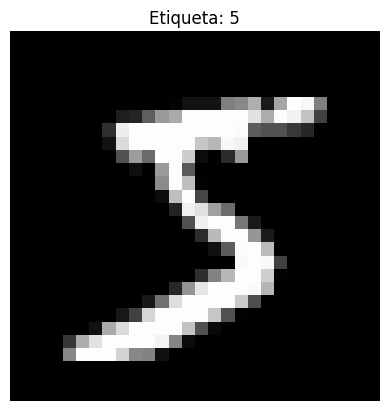

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.8681 - loss: 0.4462 - val_accuracy: 0.9773 - val_loss: 0.0846
Epoch 2/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9740 - loss: 0.0904 - val_accuracy: 0.9823 - val_loss: 0.0660
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9705 - loss: 0.0838
Accuracy en test: 0.9765999913215637


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Cargar datos
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Mostrar una imagen
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis("off")
plt.show()

# Modelo CNN simple
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Entrenar
model.fit(X_train, y_train, epochs=2, validation_split=0.1)

# Evaluar
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy en test:", acc)

## RNN / LSTM — predicción simple de serie temporal

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3950
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2979
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2350
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1668
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0705
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step


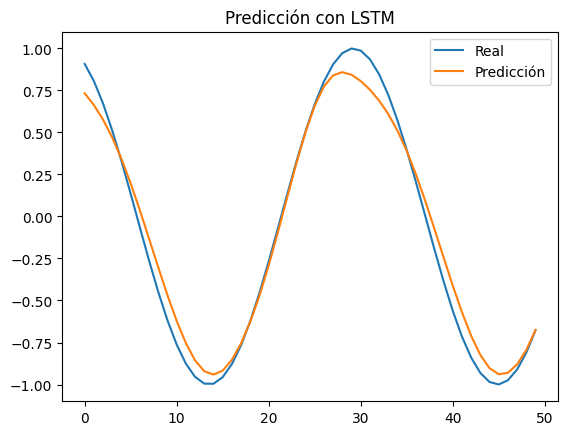

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Serie sintética
x = np.linspace(0, 100, 500)
serie = np.sin(x)

# Crear ventanas
window = 10
X, y = [], []
for i in range(len(serie) - window):
    X.append(serie[i:i+window])
    y.append(serie[i+window])

X = np.array(X)
y = np.array(y)

# Reformar para LSTM: [muestras, pasos de tiempo, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Modelo LSTM
model = models.Sequential([
    layers.LSTM(32, input_shape=(window, 1)),
    layers.Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=5, verbose=1)

# Predicción
pred = model.predict(X[:50])

plt.plot(y[:50], label="Real")
plt.plot(pred, label="Predicción")
plt.legend()
plt.title("Predicción con LSTM")
plt.show()

## Autoencoder — compresión / reconstrucción de imágenes

Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3940 - val_loss: 0.1966
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1854 - val_loss: 0.1596
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1549 - val_loss: 0.1399
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1373 - val_loss: 0.1272
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1251 - val_loss: 0.1181
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


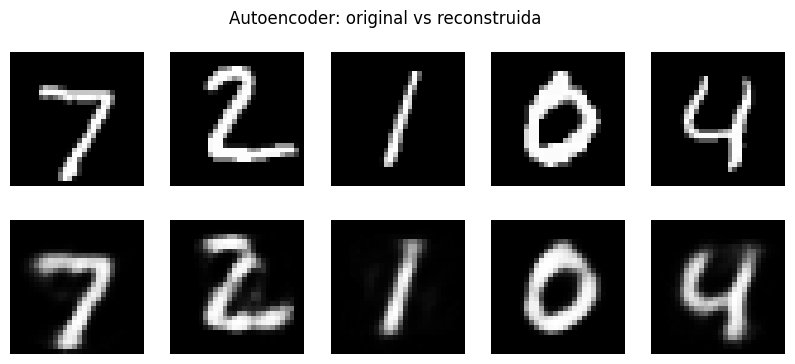

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Cargar datos
(X_train, _), (X_test, _) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar imágenes
X_train = X_train.reshape((-1, 28*28))
X_test = X_test.reshape((-1, 28*28))

# Autoencoder simple
input_dim = 28 * 28
encoding_dim = 32

input_img = layers.Input(shape=(input_dim,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = layers.Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenar
autoencoder.fit(X_train, X_train, epochs=5, batch_size=256, shuffle=True, validation_split=0.1)

# Reconstrucción
decoded_imgs = autoencoder.predict(X_test[:5])

# Mostrar originales vs reconstruidas
plt.figure(figsize=(10, 4))
for i in range(5):
    # original
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # reconstruida
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Autoencoder: original vs reconstruida")
plt.show()

## Transformer / modelo preentrenado — análisis de sentimiento

In [2]:
!pip -q install transformers

from transformers import pipeline

classifier = pipeline("sentiment-analysis")

textos = [
    "Me encantó esta clase de redes neuronales",
    "Este contenido me confundió bastante",
    "La explicación estuvo clara y útil"
]

resultados = classifier(textos)

for texto, resultado in zip(textos, resultados):
    print(f"Texto: {texto}")
    print(f"Resultado: {resultado}")
    print("-" * 50)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Texto: Me encantó esta clase de redes neuronales
Resultado: {'label': 'POSITIVE', 'score': 0.916118860244751}
--------------------------------------------------
Texto: Este contenido me confundió bastante
Resultado: {'label': 'POSITIVE', 'score': 0.8559314012527466}
--------------------------------------------------
Texto: La explicación estuvo clara y útil
Resultado: {'label': 'POSITIVE', 'score': 0.698724091053009}
--------------------------------------------------
